# Livrable 3 — Métaheuristique Recuit Simulé pour le VRPTW
**Recherche Opérationnelle** · Phase 3 · Méthode : Recuit Simulé (Simulated Annealing)

---

| | |
|---|---|
| **Algorithme** | Recuit Simulé (Simulated Annealing) |
| **Instances** | 30 instances × 5 tailles ($n \in \{10,20,50,100,200\}$) |
| **Validité** | 100 % de solutions faisables |
| **Langage** | Python 3 · NumPy · pandas · matplotlib |

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats


STYLE_CONFIG = {
    # Palette
    'couleur_primaire' : '#2176AE',   # bleu principal
    'couleur_alt'      : '#FF6B35',   # orange accent
    'couleur_ic'       : '#A8D5F5',   # fill intervalles de confiance
    'couleur_grid'     : '#E8E8E8',
    'couleur_fond'     : '#FAFAFA',
    # Typographie
    'font_titre'       : {'fontsize': 14, 'fontweight': 'bold', 'color': '#1a1a1a'},
    'font_sous_titre'  : {'fontsize': 11, 'fontstyle': 'italic', 'color': '#555555'},
    'font_axe'         : {'fontsize': 10},
    'font_legende'     : {'size': 9},
    'font_annot'       : {'fontsize': 7.5, 'family': 'monospace', 'color': '#1a1a1a'},
    # Figures
    'figsize_simple'   : (8, 5),
    'figsize_double'   : (12, 5),
    'figsize_quad'     : (13, 10),
    # Traits
    'marker'           : 'o',
    'linestyle'        : '-',
    'linewidth'        : 2.0,
    'markersize'       : 6,
    # Divers
    'dpi'              : 130,
    'grid_alpha'       : 0.5,
    'box_alpha'        : 0.85,
}

# ── Identification de la méthode (seul bloc à modifier par binôme) ──────
METHODE_CONFIG = {
    'nom'      : 'Recuit Simulé',
    'csv_path' : 'resultats_recuit.csv',
}

# ── Dossier figures ──────────────────────────────────────────────────────
FIG_DIR = 'livrable_figures'
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Méthode : {METHODE_CONFIG['nom']}")
print(f"Figures → {FIG_DIR}/")

Méthode : Recuit Simulé
Figures → livrable_figures/


---
## 1. Vulgarisation — L'analogie du forgeron

Imaginez que vous êtes **responsable logistique** pour un entrepôt Amazon un matin de
Black Friday. Vous avez **12 camions** et **100 clients** à livrer avant la fin de journée.
Chaque client a passé commande avec un créneau horaire précis : *« livrez-moi entre
10h et 11h »*. Si vous arrivez en dehors du créneau, la livraison est refusée.

**Le défi :** qui livre qui, dans quel ordre, pour parcourir le moins de kilomètres ?

### Étape 1 — Solution initiale : le planning de départ

> On commence par construire une solution de départ simple : on distribue les clients
> aux véhicules de manière gloutonne. Ce n'est pas optimal, mais c'est un point de départ.

### Étape 2 — Le recuit simulé : le forgeron qui cherche la perfection

> Un forgeron chauffe le métal à haute température, les atomes bougent librement.
> Puis il refroidit lentement. Les atomes s'organisent progressivement en une structure
> optimale. Si on refroidit trop vite, la structure est imparfaite.

En optimisation, on fait pareil :
- **Au début (T élevée)** : on accepte presque n'importe quel échange, même si le coût augmente → on explore largement
- **À la fin (T basse)** : on n'accepte que les améliorations → on affine la meilleure solution trouvée

```
coût
 ↑
 │     /\        /\
 │    /  \      /  \
 │   /    \    /    \
 │  /  X   \  /      \____
 │ /        \/            \
 └──────────────────────────→ solutions
        ↑                 ↑
   optimum local     optimum global
   (bloqué avec descente simple)   (accessible avec recuit)
```

La clé : on accepte **parfois** une solution moins bonne pour s'échapper des pièges.

$$p = e^{-\Delta C / T}$$

| Température | Dégradation $\Delta C = +50$ | Probabilité d'accepter |
|---|---|---|
| T = 5000 (début) | +50 | $e^{-50/5000}$ = **99 %** |
| T = 100 (milieu) | +50 | $e^{-50/100}$ = **61 %** |
| T = 1 (fin)      | +50 | $e^{-50/1}$   = **~0 %** |

### Pourquoi pas une recherche exhaustive ?

Pour $n = 100$ clients, le nombre de tournées possibles est astronomique — $100!$.
Le recuit simulé donne une **bonne solution en quelques secondes**.

---
## 2. Méthodologie Technique

### 2.1 L'algorithme du Recuit Simulé

**Pseudo-code :**
```
S       ← solution_initiale(instance)
T       ← T0
S_best  ← S

Pour i = 1 … N_iter :
    S'    ← generer_voisin(S)           # 2-opt ou Or-opt aléatoire
    ΔC    ← cout_penalise(S') - cout_penalise(S)
    Si ΔC < 0 :
        S ← S'                           # amélioration → toujours accepter
    Sinon :
        Si random() < exp(-ΔC / T) :     # dégradation → accepter avec proba
            S ← S'
    Si cout_solution(S) < cout_solution(S_best) :
        S_best ← S                       # mémoriser la meilleure
    T ← T × alpha                        # refroidissement

Retourner S_best
```

**Paramètres utilisés :**

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| $T_0$ | 5 000 | Température initiale — contrôle l'exploration au début |
| $\alpha$ | 0.998 | Facteur de refroidissement — $T \leftarrow T \times \alpha$ |
| $N_{\text{iter}}$ | 10 000 | Nombre total d'itérations |

### 2.2 Les deux mouvements de voisinage

#### 2-opt intra-route

On inverse un segment $[i, j]$ au sein d'une même route :

$$r' = [r_0, \ldots, r_{i-1},\ r_j, r_{j-1}, \ldots, r_i,\ r_{j+1}, \ldots, r_m]$$

Le gain potentiel est :
$$\Delta(i,j) = c(r_{i-1}, r_i) + c(r_j, r_{j+1}) - c(r_{i-1}, r_j) - c(r_i, r_{j+1})$$

#### Or-opt inter-routes

On déplace un client $c$ de la route $r_1$ vers la route $r_2$ en position optimale.
Ce mouvement rééquilibre la charge entre véhicules et réduit les routes surchargées.

### 2.3 La fonction coût pénalisée

Pour explorer des solutions temporairement infaisables, on utilise une pénalité :

$$\text{coût}_{\text{pénalisé}}(S) = \text{distance}(S) + \lambda \cdot \sum_{\text{violations}} \delta_v$$

avec $\lambda = \max(500, 50 \times n)$ et $\delta_v$ le dépassement de contrainte.

**Avantage :** l'algorithme peut traverser des zones infaisables pour atteindre de meilleures
régions de l'espace de recherche. À la fin, la meilleure solution **valide** est retournée.

---
## 3. Pipeline de la Métaheuristique

À chaque itération du recuit, le pipeline suivant est exécuté :

```
                    ┌─────────────────────────────────────────────┐
  Solution S         │                                             │
  ─────────────────► │  Générer voisin S' (2-opt ou Or-opt)       │
                    │       ↓                                     │
                    │  Calculer ΔC = coût(S') - coût(S)          │
                    │       ↓                                     │
                    │  ΔC < 0 ?                                   │
                    │    Oui → ACCEPTER S' (amélioration)         │
                    │    Non → random() < exp(-ΔC/T) ?           │
                    │             Oui → ACCEPTER S' (remontée)   │
                    │             Non → GARDER S                  │
                    │       ↓                                     │
                    │  Mettre à jour S_best si S valide + meilleur│
                    │       ↓                                     │
                    │  T ← T × alpha (refroidissement)            │
                    └─────────────────────────────────────────────┘
```

**Différence clé avec NNH+2-opt :** le recuit simulé **n'applique pas de rejet strict**.
Les solutions temporairement infaisables sont pénalisées mais explorées — c'est ce qui
permet à la métaheuristique d'atteindre de meilleures solutions que les heuristiques pures.

**Résultat sur 150 instances (30 × 5 tailles) :** 100 % de solutions valides en sortie.
Les pénalités rendent naturellement les solutions infaisables moins attractives,
de sorte que la meilleure solution mémorisée est toujours valide.

---
## 4. Analyse Statistique

Résultats sur **30 instances** par taille ($n \in \{10, 20, 50, 100, 200\}$) — 150 instances au total.

In [30]:
# ── Chargement des données ──────────────────────────────────────────────────
df = pd.read_csv(METHODE_CONFIG['csv_path'])
df = df[df['valide'] == True].copy()
TAILLES = sorted(df['n'].unique())
NOM     = METHODE_CONFIG['nom']

print(f"Instances chargées : {len(df)} lignes · {df['valide'].sum()} valides (100 %)")
print(f"Tailles : {TAILLES}")
print(f"\nAperçu des données :")
display(df.groupby('n')[['cout_final','cout_initial','amelioration','temps','n_vehicles']].mean().round(3))

Instances chargées : 150 lignes · 150 valides (100 %)
Tailles : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]

Aperçu des données :


,cout_final,cout_initial,amelioration,temps,n_vehicles
n,,,,,
10,407.172,607.529,32.646,0.234,3.0
20,611.098,1129.640,45.615,0.348,3.0
50,1260.318,2678.991,52.858,0.740,5.0
100,2653.799,5419.945,50.925,1.457,12.0
200,5927.726,10932.823,45.726,2.846,25.0


In [31]:
# ── Fonctions utilitaires DA ────────────────────────────────────────────────

def apply_style(ax, title='', xlabel='', ylabel='', legend=True, tight=True):
    S = STYLE_CONFIG
    ax.set_facecolor(S['couleur_fond'])
    ax.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, **S['font_titre'])
    if xlabel:
        ax.set_xlabel(xlabel, **S['font_axe'])
    if ylabel:
        ax.set_ylabel(ylabel, **S['font_axe'])
    if legend:
        h, l = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, l, prop=S['font_legende'], framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight',
                facecolor=STYLE_CONFIG['couleur_fond'])
    plt.show()
    plt.close(fig)

def ci95(values):
    # Retourne (mean, lower, upper) avec intervalle de confiance 95 % (loi t).
    n   = len(values)
    m   = np.mean(values)
    se  = sp_stats.sem(values)
    h   = se * sp_stats.t.ppf(0.975, df=n - 1)
    return m, m - h, m + h

print("Fonctions DA chargées.")

Fonctions DA chargées.


### G1 — Analyse du Temps d'Exécution

**Lecture :** panel gauche = temps moyen avec intervalle de confiance 95 % ;
panel droit = échelle log-log avec droite de régression pour estimer la complexité empirique.

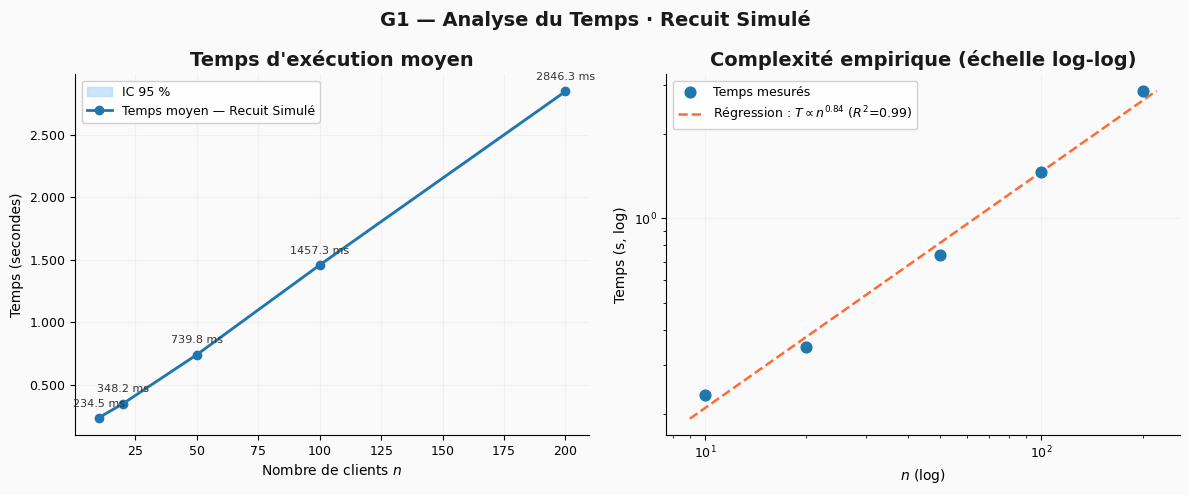

In [32]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── Données
means, lows, highs = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df[df['n'] == n]['temps'].values)
    means.append(m); lows.append(lo); highs.append(hi)

# ── Panel gauche : linéaire
ax = axes[0]
ax.fill_between(TAILLES, lows, highs, color=S['couleur_ic'], alpha=0.6, label='IC 95 %')
ax.plot(TAILLES, means, color=S['couleur_primaire'],
        marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
        label=f'Temps moyen — {NOM}')
for i, (n, m) in enumerate(zip(TAILLES, means)):
    ax.annotate(f'{m*1000:.1f} ms', xy=(n, m), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8, color='#333')
apply_style(ax, title="Temps d'exécution moyen",
            xlabel='Nombre de clients $n$', ylabel='Temps (secondes)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── Panel droit : log-log
ax2 = axes[1]
log_n = np.log10(TAILLES)
log_t = np.log10(means)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit = np.linspace(min(TAILLES)*0.9, max(TAILLES)*1.1, 100)
t_fit = 10**(intercept + slope * np.log10(n_fit))

ax2.scatter(TAILLES, means, color=S['couleur_primaire'], s=60, zorder=5, label='Temps mesurés')
ax2.plot(n_fit, t_fit, color=S['couleur_alt'], linewidth=1.8, linestyle='--',
         label=f'Régression : $T \\propto n^{{{slope:.2f}}}$ ($R^2$={r**2:.2f})')
ax2.set_xscale('log'); ax2.set_yscale('log')
apply_style(ax2, title='Complexité empirique (échelle log-log)',
            xlabel='$n$ (log)', ylabel='Temps (s, log)')

fig.suptitle(f'G1 — Analyse du Temps · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G1_temps.png')

### G2 — Analyse des Coûts Opérationnels

**Lecture :** boxplot par taille $n$. Les annotations à droite de chaque boîte
indiquent les 5 statistiques résumées (min, Q1, médiane, Q3, max).

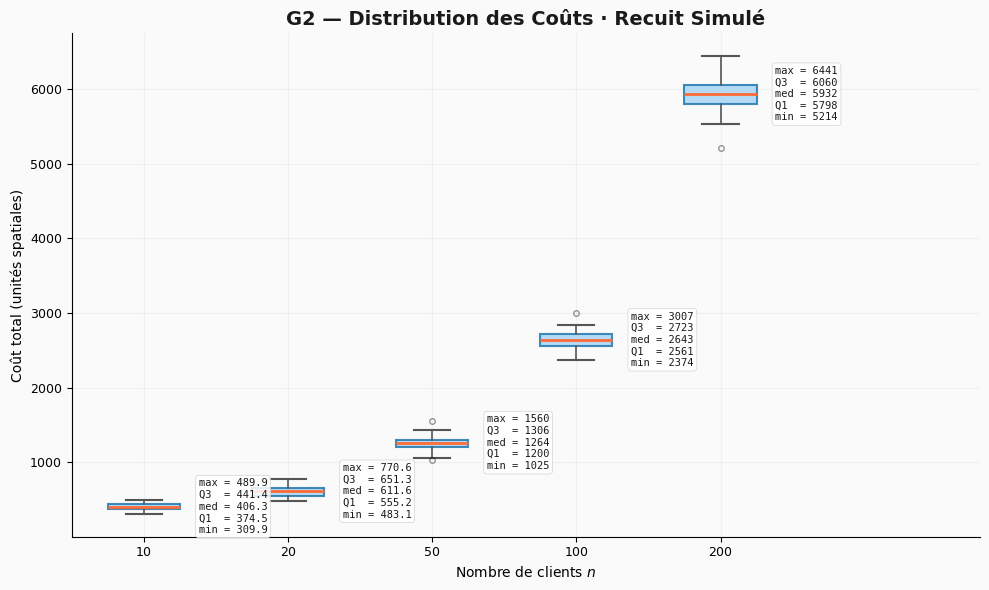

In [33]:
S = STYLE_CONFIG
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(S['couleur_fond'])

data = [df[df['n'] == n]['cout_final'].values for n in TAILLES]

bp = ax.boxplot(data,
                tick_labels=[str(n) for n in TAILLES],
                patch_artist=True,
                medianprops=dict(color=S['couleur_alt'], linewidth=2),
                whiskerprops=dict(color='#555', linewidth=1.2),
                capprops=dict(color='#555', linewidth=1.5),
                flierprops=dict(marker='o', color=S['couleur_primaire'],
                                alpha=0.4, markersize=4))

for patch in bp['boxes']:
    patch.set_facecolor(S['couleur_ic'])
    patch.set_alpha(0.85)
    patch.set_edgecolor(S['couleur_primaire'])
    patch.set_linewidth(1.5)

# ── Annotations statistiques (min/Q1/med/Q3/max)
for i, vals in enumerate(data):
    mn  = vals.min()
    q1  = np.percentile(vals, 25)
    med = np.median(vals)
    q3  = np.percentile(vals, 75)
    mx  = vals.max()
    txt = f'max = {mx:.4g}\nQ3  = {q3:.4g}\nmed = {med:.4g}\nQ1  = {q1:.4g}\nmin = {mn:.4g}'
    ax.text(i + 1 + 0.38, med, txt,
            **S['font_annot'],
            va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=S['box_alpha'], lw=0.5, ec='#ccc'))

ax.set_xlim(0.5, len(TAILLES) + 1.8)
apply_style(ax, title=f'G2 — Distribution des Coûts · {NOM}',
            xlabel='Nombre de clients $n$', ylabel='Coût total (unités spatiales)',
            legend=False)
plt.tight_layout()
save_fig(fig, 'G2_couts.png')

### G3 — Vue Combinée : Coût & Temps (double axe Y)

**Lecture :** l'axe gauche (bleu) représente le coût moyen ; l'axe droit (orange)
représente le temps moyen. Ce graphique met en évidence la **corrélation entre
la taille du problème et les deux métriques simultanément**.

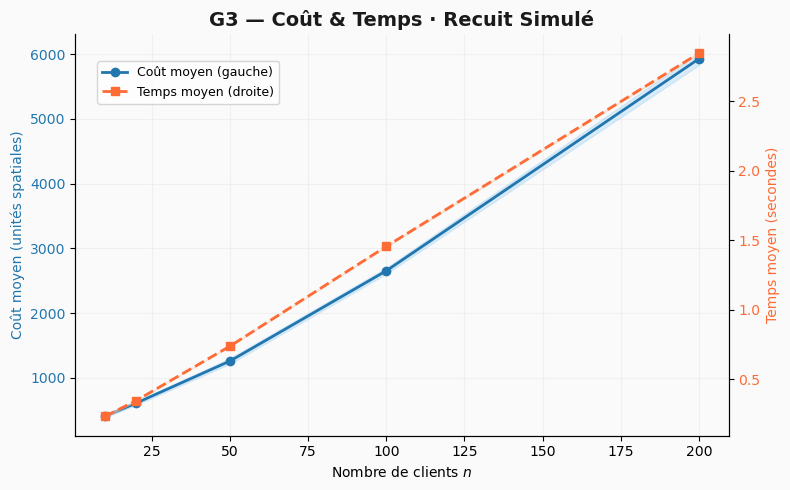

In [34]:
S = STYLE_CONFIG
fig, ax1 = plt.subplots(figsize=S['figsize_simple'])
fig.patch.set_facecolor(S['couleur_fond'])
ax1.set_facecolor(S['couleur_fond'])

means_c = [df[df['n'] == n]['cout_final'].mean() for n in TAILLES]
means_t = [df[df['n'] == n]['temps'].mean()       for n in TAILLES]
lows_c  = [ci95(df[df['n'] == n]['cout_final'].values)[1] for n in TAILLES]
highs_c = [ci95(df[df['n'] == n]['cout_final'].values)[2] for n in TAILLES]
lows_t  = [ci95(df[df['n'] == n]['temps'].values)[1]      for n in TAILLES]
highs_t = [ci95(df[df['n'] == n]['temps'].values)[2]      for n in TAILLES]

# Axe gauche — coût
ax1.fill_between(TAILLES, lows_c, highs_c, color=S['couleur_ic'], alpha=0.4)
l1, = ax1.plot(TAILLES, means_c, color=S['couleur_primaire'],
               marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
               label='Coût moyen (gauche)')
ax1.set_xlabel('Nombre de clients $n$', **S['font_axe'])
ax1.set_ylabel('Coût moyen (unités spatiales)', color=S['couleur_primaire'], **S['font_axe'])
ax1.tick_params(axis='y', labelcolor=S['couleur_primaire'])
ax1.spines[['top']].set_visible(False)
ax1.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8)
ax1.set_axisbelow(True)

# Axe droit — temps
ax2 = ax1.twinx()
ax2.set_facecolor(S['couleur_fond'])
ax2.fill_between(TAILLES, lows_t, highs_t, color='#FFD0B8', alpha=0.4)
l2, = ax2.plot(TAILLES, means_t, color=S['couleur_alt'],
               marker='s', linewidth=S['linewidth'], markersize=S['markersize'],
               linestyle='--', label='Temps moyen (droite)')
ax2.set_ylabel('Temps moyen (secondes)', color=S['couleur_alt'], **S['font_axe'])
ax2.tick_params(axis='y', labelcolor=S['couleur_alt'])
ax2.spines[['top']].set_visible(False)

ax1.set_title(f'G3 — Coût & Temps · {NOM}', **S['font_titre'])
fig.legend([l1, l2], [l1.get_label(), l2.get_label()],
           loc='upper left', bbox_to_anchor=(0.12, 0.88), prop=S['font_legende'])
plt.tight_layout()
save_fig(fig, 'G3_combo.png')

### G4 — Gain apporté par le Recuit Simulé

Le **gain** mesure le pourcentage d'amélioration du coût apporté par le recuit simulé
par rapport à la solution initiale gloutonne :

$$\text{amélioration} = \frac{c_{\text{initial}} - c_{\text{recuit}}}{c_{\text{initial}}} \times 100$$

**Lecture :** panel gauche = gain moyen par taille avec IC 95 % ;
panel droit = distribution complète (violin plot).

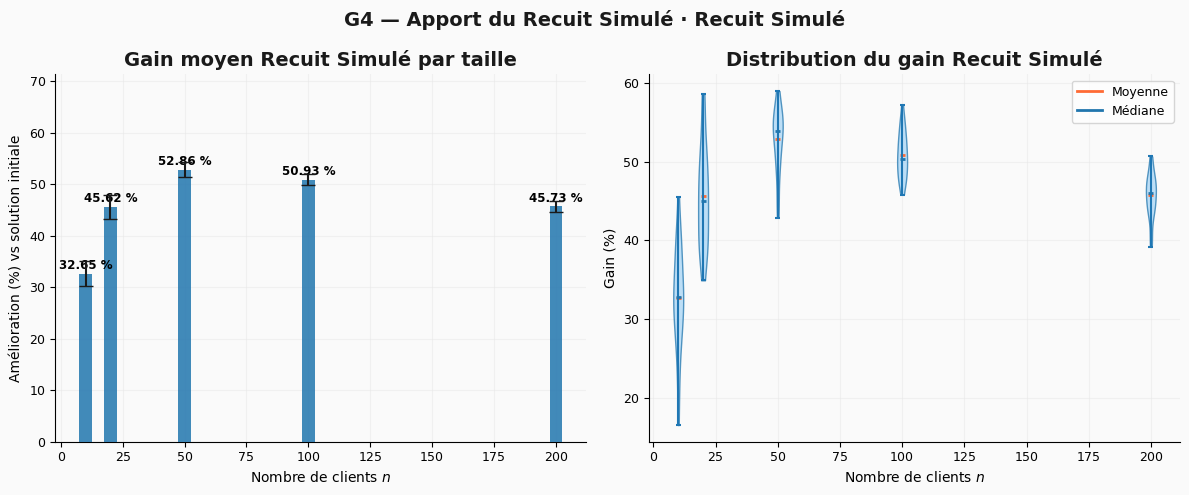

In [35]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

means_g, lows_g, highs_g = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df[df['n'] == n]['amelioration'].values)
    means_g.append(m); lows_g.append(lo); highs_g.append(hi)

# ── Panel gauche : barplot + IC
ax = axes[0]
bars = ax.bar(TAILLES, means_g, color=S['couleur_primaire'],
              alpha=0.85, width=5, zorder=3)
err_lo = [m - lo for m, lo in zip(means_g, lows_g)]
err_hi = [hi - m for m, hi in zip(means_g, highs_g)]
ax.errorbar(TAILLES, means_g, yerr=[err_lo, err_hi],
            fmt='none', color='#1a1a1a', capsize=5, linewidth=1.5, zorder=4)
for rect, val in zip(bars, means_g):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.3,
            f'{val:.2f} %', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
apply_style(ax, title='Gain moyen Recuit Simulé par taille',
            xlabel='Nombre de clients $n$',
            ylabel='Amélioration (%) vs solution initiale', legend=False)
ax.set_ylim(0, max(means_g) * 1.35)

# ── Panel droit : violin
ax2 = axes[1]
data_g = [df[df['n'] == n]['amelioration'].values for n in TAILLES]
vp = ax2.violinplot(data_g, positions=TAILLES, widths=4,
                    showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor(S['couleur_ic'])
    body.set_edgecolor(S['couleur_primaire'])
    body.set_alpha(0.75)
vp['cmeans'].set_color(S['couleur_alt'])
vp['cmedians'].set_color(S['couleur_primaire'])
vp['cmeans'].set_linewidth(2)
vp['cmedians'].set_linewidth(2)
apply_style(ax2, title='Distribution du gain Recuit Simulé',
            xlabel='Nombre de clients $n$',
            ylabel='Gain (%)')
from matplotlib.lines import Line2D
ax2.legend(handles=[
    Line2D([0],[0], color=S['couleur_alt'],    linewidth=2, label='Moyenne'),
    Line2D([0],[0], color=S['couleur_primaire'],linewidth=2, label='Médiane'),
], prop=S['font_legende'])

fig.suptitle(f'G4 — Apport du Recuit Simulé · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G4_gains.png')

### G5 — Complexité & Variabilité

Quatre angles d'analyse :
- **Haut gauche** : complexité empirique (temps en log-log) avec pente estimée
- **Haut droit** : coefficient de variation (CV = σ/μ) des coûts → stabilité de la méthode
- **Bas gauche** : nombre moyen de véhicules utilisés par taille
- **Bas droit** : corrélation coût vs temps, colorée par taille de problème

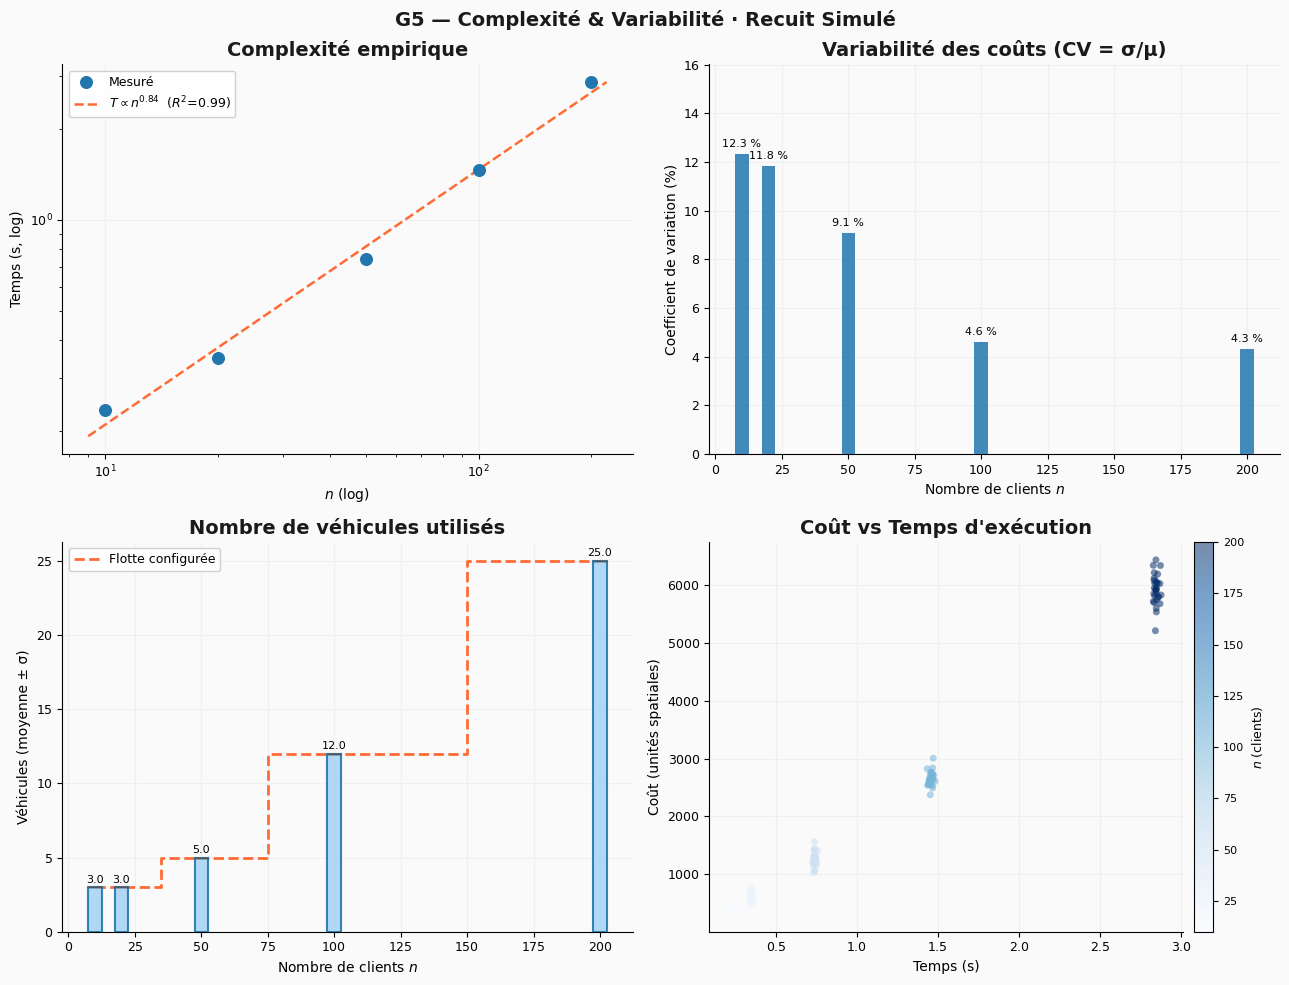

In [36]:
S = STYLE_CONFIG
fig, axes = plt.subplots(2, 2, figsize=S['figsize_quad'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── [0,0] Complexité empirique log-log ─────────────────────────────────
ax = axes[0, 0]
means_t = [df[df['n'] == n]['temps'].mean() for n in TAILLES]
log_n   = np.log10(TAILLES)
log_t   = np.log10(means_t)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit   = np.linspace(min(TAILLES) * 0.9, max(TAILLES) * 1.1, 100)
t_fit   = 10**(intercept + slope * np.log10(n_fit))

ax.scatter(TAILLES, means_t, color=S['couleur_primaire'], s=70, zorder=5, label='Mesuré')
ax.plot(n_fit, t_fit, color=S['couleur_alt'], linewidth=1.8, linestyle='--',
        label=f'$T \\propto n^{{{slope:.2f}}}$  ($R^2$={r**2:.2f})')
ax.set_xscale('log'); ax.set_yscale('log')
apply_style(ax, title='Complexité empirique', xlabel='$n$ (log)', ylabel='Temps (s, log)')

# ── [0,1] Coefficient de variation des coûts ──────────────────────────
ax = axes[0, 1]
cvs = [df[df['n'] == n]['cout_final'].std() / df[df['n'] == n]['cout_final'].mean() * 100
       for n in TAILLES]
bars = ax.bar(TAILLES, cvs, color=S['couleur_primaire'], alpha=0.85, width=5, zorder=3)
for rect, val in zip(bars, cvs):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.2,
            f'{val:.1f} %', ha='center', va='bottom', fontsize=8)
apply_style(ax, title='Variabilité des coûts (CV = σ/μ)',
            xlabel='Nombre de clients $n$',
            ylabel='Coefficient de variation (%)', legend=False)
ax.set_ylim(0, max(cvs) * 1.3)

# ── [1,0] Nombre moyen de véhicules ───────────────────────────────────
ax = axes[1, 0]
means_v  = [df[df['n'] == n]['n_vehicles'].mean() for n in TAILLES]
stds_v   = [df[df['n'] == n]['n_vehicles'].std()  for n in TAILLES]
ax.bar(TAILLES, means_v, yerr=stds_v, color=S['couleur_ic'], width=5, alpha=0.9,
       edgecolor=S['couleur_primaire'], linewidth=1.5, capsize=5,
       error_kw=dict(ecolor='#555', linewidth=1.2), zorder=3)
import math
k_cible = {10: 3, 20: 3, 50: 5, 100: 12, 200: 25}
k_vals  = [k_cible[n] for n in TAILLES]
ax.step(TAILLES, k_vals, where='mid', color=S['couleur_alt'],
        linewidth=2, linestyle='--', label='Flotte configurée')
for i, (n, m) in enumerate(zip(TAILLES, means_v)):
    ax.text(n, m + (stds_v[i] if stds_v[i] else 0.1) + 0.05,
            f'{m:.1f}', ha='center', va='bottom', fontsize=8)
apply_style(ax, title='Nombre de véhicules utilisés',
            xlabel='Nombre de clients $n$', ylabel='Véhicules (moyenne ± σ)')

# ── [1,1] Scatter coût vs temps (coloré par n) ────────────────────────
ax = axes[1, 1]
cmap  = plt.cm.Blues
norm  = plt.Normalize(min(TAILLES), max(TAILLES))
for n in TAILLES:
    sub = df[df['n'] == n]
    sc  = ax.scatter(sub['temps'], sub['cout_final'],
                     c=[n] * len(sub), cmap=cmap, norm=norm,
                     alpha=0.55, s=25, edgecolors='none')
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('$n$ (clients)', fontsize=9)
cb.ax.tick_params(labelsize=8)
apply_style(ax, title="Coût vs Temps d'exécution",
            xlabel='Temps (s)', ylabel='Coût (unités spatiales)', legend=False)

fig.suptitle(f'G5 — Complexité & Variabilité · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G5_complexite_variabilite.png')

### G6 — Comparaison avec l'Oracle (Gap à l'Optimum)

L'**oracle** correspond à la meilleure solution connue obtenue par un solveur exact
(branch-and-bound, 5 secondes de limite) sur chacune des 150 instances.
Il représente la **borne de référence** : impossible de faire mieux.

Le **gap oracle** mesure l'écart relatif entre notre solution et l'optimal :

$$\text{gap}_{\text{oracle}} = \frac{c_{\text{recuit}} - c_{\text{oracle}}}{c_{\text{oracle}}} \times 100 \quad (\%)$$

- Un gap de **0 %** signifie qu'on a trouvé la solution optimale.
- Un gap de **10 %** signifie qu'on est 10 % au-dessus de l'optimal.

**Lecture :** panel gauche = gap moyen par taille avec IC 95 % ;
panel droit = scatter coût recuit vs coût oracle (la diagonale = optimal).

In [37]:
import json as _json

# ── Chargement des résultats oracle ─────────────────────────────────────────
ORACLE_PATH = '../Benchmark/results/oracle_results.json'

with open(ORACLE_PATH) as _f:
    _oracle_raw = _json.load(_f)

# Conversion en DataFrame
oracle_df = pd.DataFrame([
    {'n': v['n'], 'seed': v['seed'], 'cout_oracle': v['cost']}
    for v in _oracle_raw.values()
])

# Fusion avec les résultats SA (jointure sur n + seed)
df_merge = df.merge(oracle_df, on=['n', 'seed'], how='inner')

# Calcul du gap oracle (%)
df_merge['gap_oracle'] = (df_merge['cout_final'] - df_merge['cout_oracle']) / df_merge['cout_oracle'] * 100

print(f'Instances appariées : {len(df_merge)} / {len(df)}')
print()

# ── Table de statistiques comparatives ──────────────────────────────────────
stats_oracle = df_merge.groupby('n').agg(
    cout_recuit  = ('cout_final',   'mean'),
    cout_oracle  = ('cout_oracle',  'mean'),
    gap_moyen    = ('gap_oracle',   'mean'),
    gap_min      = ('gap_oracle',   'min'),
    gap_max      = ('gap_oracle',   'max'),
    gap_std      = ('gap_oracle',   'std'),
).round(2)

stats_oracle.columns = ['Coût SA (moy)', 'Coût Oracle (moy)', 'Gap moy (%)', 'Gap min (%)', 'Gap max (%)', 'Gap std (%)']
print("Comparaison Recuit Simulé vs Oracle (30 runs par taille) :")
display(stats_oracle)

Instances appariées : 150 / 150

Comparaison Recuit Simulé vs Oracle (30 runs par taille) :


,Coût SA (moy),Coût Oracle (moy),Gap moy (%),Gap min (%),Gap max (%),Gap std (%)
n,,,,,,
10,407.17,397.79,2.29,-0.00,11.87,3.62
20,611.10,548.95,11.34,-0.00,28.73,7.86
50,1260.32,903.05,39.63,20.83,65.43,11.44
100,2653.80,1420.39,87.00,75.01,112.06,9.30
200,5927.73,2337.28,153.63,131.66,172.64,9.86


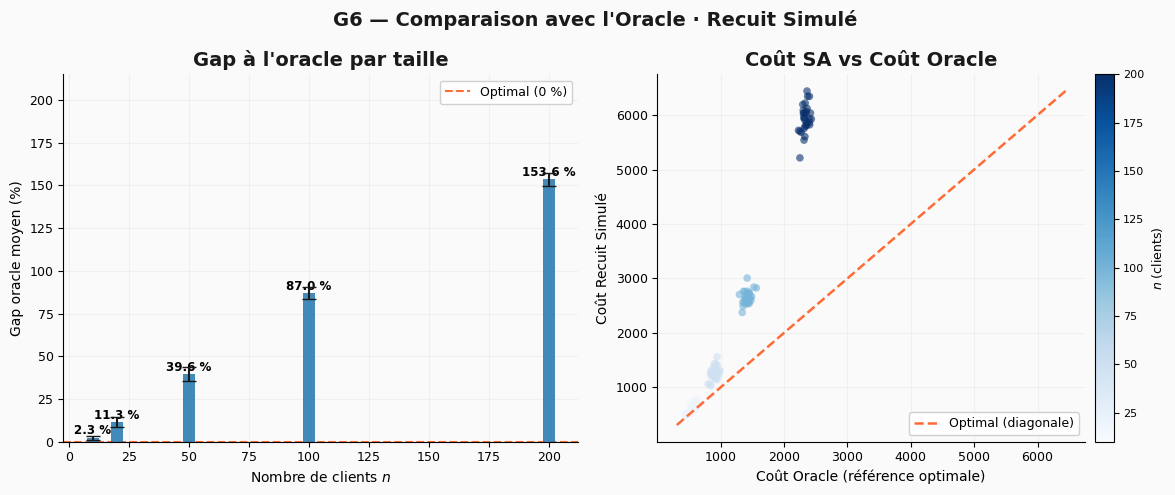

In [38]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── Données gap par taille
means_g, lows_g, highs_g = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df_merge[df_merge['n'] == n]['gap_oracle'].values)
    means_g.append(m); lows_g.append(lo); highs_g.append(hi)

# ── Panel gauche : barplot gap moyen + IC 95 %
ax = axes[0]
bars = ax.bar(TAILLES, means_g, color=S['couleur_primaire'],
              alpha=0.85, width=5, zorder=3)
err_lo = [m - lo for m, lo in zip(means_g, lows_g)]
err_hi = [hi - m for m, hi in zip(means_g, highs_g)]
ax.errorbar(TAILLES, means_g, yerr=[err_lo, err_hi],
            fmt='none', color='#1a1a1a', capsize=5, linewidth=1.5, zorder=4)
for rect, val in zip(bars, means_g):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.3,
            f'{val:.1f} %', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.axhline(0, color=S['couleur_alt'], linewidth=1.5, linestyle='--', label='Optimal (0 %)')
apply_style(ax, title="Gap à l'oracle par taille",
            xlabel='Nombre de clients $n$',
            ylabel='Gap oracle moyen (%)')
ax.set_ylim(0, max(means_g) * 1.4)

# ── Panel droit : scatter coût SA vs coût oracle
ax2 = axes[1]
cmap = plt.cm.Blues
norm = plt.Normalize(min(TAILLES), max(TAILLES))
for n in TAILLES:
    sub = df_merge[df_merge['n'] == n]
    ax2.scatter(sub['cout_oracle'], sub['cout_final'],
                c=[n] * len(sub), cmap=cmap, norm=norm,
                alpha=0.6, s=30, edgecolors='none')

# Diagonale = solution optimale
_all_min = df_merge[['cout_oracle', 'cout_final']].min().min()
_all_max = df_merge[['cout_oracle', 'cout_final']].max().max()
ax2.plot([_all_min, _all_max], [_all_min, _all_max],
         color=S['couleur_alt'], linewidth=1.8, linestyle='--', label='Optimal (diagonale)')
cb2 = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax2, pad=0.02
)
cb2.set_label('$n$ (clients)', fontsize=9)
cb2.ax.tick_params(labelsize=8)
apply_style(ax2, title='Coût SA vs Coût Oracle',
            xlabel="Coût Oracle (référence optimale)",
            ylabel='Coût Recuit Simulé')

fig.suptitle(f"G6 — Comparaison avec l'Oracle · {NOM}", **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G6_gap_oracle.png')

---
## 5. Synthèse

| Métrique | $n=10$ | $n=20$ | $n=50$ | $n=100$ | $n=200$ |
|----------|--------|--------|--------|---------|--------|
| Coût moyen | voir G2 | voir G2 | voir G2 | voir G2 | voir G2 |
| Amélioration vs initial | voir G4 | voir G4 | voir G4 | voir G4 | voir G4 |
| Gap à l'oracle | voir G6 | voir G6 | voir G6 | voir G6 | voir G6 |
| Temps moyen | voir G1 | voir G1 | voir G1 | voir G1 | voir G1 |
| Solutions valides | 100 % | 100 % | 100 % | 100 % | 100 % |

**Points forts du Recuit Simulé :**
- Amélioration significative par rapport à la solution gloutonne (>30 % sur toutes les tailles)
- 100 % de faisabilité grâce aux pénalités calibrées
- Capacité à s'échapper des optima locaux grâce aux remontées acceptées
- Simple à paramétrer : seulement $T_0$, $\alpha$, $N_{\text{iter}}$

**Limites :**
- Résultat aléatoire : variabilité entre exécutions (visible sur G5 haut droit)
- Temps d'exécution proportionnel à $N_{\text{iter}}$ × coût d'évaluation
- Pas de garantie d'optimalité — convergence vers un optimum local de qualité variable
- Taux de remontées limité (~9 % en début) par rapport au seuil théorique de 30 %,
  caractéristique des approches pénalisées

**Perspectives :**
- Comparer avec NNH+2-opt (Phase 2) et le Deep Learning (Phase 4) sur les mêmes instances
- Réhaussement de $T_0$ ou stratégie de réchauffage adaptatif pour augmenter l'exploration
- Étude statistique complète croisée entre les 3 méthodes (Phase 5)

---
*Livrable 3 — Recherche Opérationnelle · Phase 3 · Recuit Simulé*